In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from torch.utils.data import TensorDataset,DataLoader
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

In [2]:
iris=load_iris()
X=iris.data
y=iris.target

In [3]:
df=pd.DataFrame(X,columns=iris.feature_names)
df['target']=y

In [4]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [5]:
df.tail()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2
149,5.9,3.0,5.1,1.8,2


In [6]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [7]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [8]:
X_train=torch.tensor(X_train,dtype=torch.float32)
X_test=torch.tensor(X_test,dtype=torch.float32)
y_train=torch.tensor(y_train,dtype=torch.long)
y_test=torch.tensor(y_test,dtype=torch.long)

In [9]:
train_data=TensorDataset(X_train,y_train)
test_data=TensorDataset(X_test,y_test)
train_loader=DataLoader(train_data,batch_size=16,shuffle=True)
test_loader=DataLoader(test_data,batch_size=16)

In [10]:
class IrisClassifier(nn.Module):
  def __init__(self,input_size):
    super(IrisClassifier,self).__init__()
    self.fc1=nn.Linear(input_size,16)
    self.fc2=nn.Linear(16,8)
    self.fc3=nn.Linear(8,3)

  def forward(self,x):
    x= F.relu(self.fc1(x))
    x= F.relu(self.fc2(x))
    return self.fc3(x)

In [11]:
def train_model(model,train_loader,criterion,optimizer,epochs):
  for epoch in range(epochs):
    model.train()
    for X_batch,y_batch in train_loader:
      optimizer.zero_grad()
      outputs=model(X_batch)
      loss=criterion(outputs,y_batch)
      loss.backward()
      optimizer.step()
    if(epoch+1)%10==0:
      print(f'Epoch [{epoch+1}/{epochs}], Loss:{loss.item():.4f}')

In [12]:
model=IrisClassifier(input_size=X_train.shape[1])
criterion=nn.CrossEntropyLoss()
optimizer=optim.Adam(model.parameters(),lr=0.01)

In [13]:
train_model(model,train_loader,criterion,optimizer,epochs=100)
model.eval()
predictions,actuals=[],[]

Epoch [10/100], Loss:0.1844
Epoch [20/100], Loss:0.0087
Epoch [30/100], Loss:0.0195
Epoch [40/100], Loss:0.0095
Epoch [50/100], Loss:0.0193
Epoch [60/100], Loss:0.0143
Epoch [70/100], Loss:0.0009
Epoch [80/100], Loss:0.0089
Epoch [90/100], Loss:0.0385
Epoch [100/100], Loss:0.0008


In [14]:
with torch.no_grad():
  for X_batch,y_batch in test_loader:
    outputs=model(X_batch)
    _,predicted=torch.max(outputs,1)
    predictions.extend(predicted.numpy())
    actuals.extend(y_batch.numpy())

In [15]:
accuracy=accuracy_score(actuals,predictions)
conf_matrix=confusion_matrix(actuals,predictions)
class_report=classification_report(actuals,predictions,target_names=iris.target_names)

In [16]:
print(f'Test Accuracy: {accuracy:.2f}\n')
print("Classification Report:\n",class_report)

Test Accuracy: 1.00

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


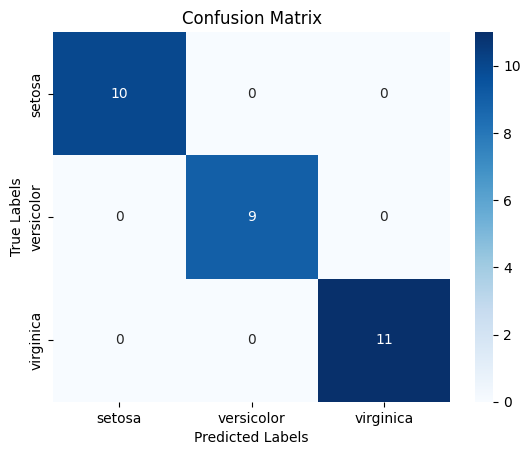

In [17]:
print("Confusion Matrix:\n",conf_matrix)
sns.heatmap(conf_matrix,annot=True,cmap='Blues',xticklabels=iris.target_names,yticklabels=iris.target_names,fmt='g')
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()

In [18]:
sample_input=X_test[5].unsqueeze(0)
with torch.no_grad():
  output=model(sample_input)
  predicted_class_index=torch.argmax(output[0]).item()
  predicted_class_label=iris.target_names[predicted_class_index]

In [19]:
print(f'Predicted class for sample input: {predicted_class_label}')
print(f'Actual class for sample input: {iris.target_names[y_test[5].item()]}')

Predicted class for sample input: setosa
Actual class for sample input: setosa


In [20]:
# Ex.No. 02
## Developing A Neural Network In Classification Model
## Reg.No: 212223230151
## Name: Prajin S